In [6]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cnx = mysql.connector.connect(
    user='root',
    password='Allaberganov_1982',
    host='localhost',
    port=3306,
    database='final_project_2'
)
cursor = cnx.cursor(buffered=True)

TAX_RATES = {
    'CA': 0.0725,
    'NY': 0.08,
    'IL': 0.0625,
    'TX': 0.0625,
    'WA': 0.065,
    'Online': 0.0
}

print("Connected to BestBuy database!")

Connected to BestBuy database!


In [7]:
def get_next_id(table, column):
    cursor.execute(f"SELECT MAX({column}) FROM {table}")
    result = cursor.fetchone()[0]
    return (result or 0) + 1

def get_store_tax(store_id):
    if store_id == 6:
        return 0.0, 'Online'
    cursor.execute("SELECT state FROM BM WHERE storeID = %s", (store_id,))
    row = cursor.fetchone()
    if row:
        state = row[0]
        return TAX_RATES.get(state, 0.0), state
    return 0.0, 'Unknown'

def show_stores():
    query = """
    SELECT s.storeID,
           CASE WHEN bm.city IS NOT NULL 
                THEN CONCAT(bm.city, ', ', bm.state)
                ELSE 'Online (bestbuy.com)' 
           END AS location
    FROM store s
    LEFT JOIN BM bm ON s.storeID = bm.storeID
    LEFT JOIN webstore w ON s.storeID = w.storeID
    ORDER BY s.storeID
    """
    df = pd.read_sql(query, cnx)
    print("\n=== Available Stores ===")
    for _, row in df.iterrows():
        print(f"  {row['storeID']}. {row['location']}")
    return df

def show_inventory(store_id):
    query = """
    SELECT p.productID, p.name, p.price,
           CASE 
               WHEN e.productID IS NOT NULL THEN 'Electronics'
               WHEN a.productID IS NOT NULL THEN 'Appliances'
               WHEN t.productID IS NOT NULL THEN 'Toys'
               WHEN f.productID IS NOT NULL THEN 'Furniture'
           END AS category
    FROM inventory i
    JOIN product p ON i.productID = p.productID
    LEFT JOIN electronics e ON p.productID = e.productID
    LEFT JOIN appliances a ON p.productID = a.productID
    LEFT JOIN toys t ON p.productID = t.productID
    LEFT JOIN furniture f ON p.productID = f.productID
    WHERE i.storeID = %s
    ORDER BY p.productID
    """
    df = pd.read_sql(query, cnx, params=[store_id])
    print(f"\n=== Inventory (Store {store_id}) ===")
    print(f"{'ID':<6}{'Product':<40}{'Price':<12}{'Category'}")
    print("-" * 70)
    for _, row in df.iterrows():
        print(f"{row['productID']:<6}{row['name']:<40}${row['price']:<11}{row['category']}")
    return df

def register_member():
    print("\n=== Create Account ===")
    name = input("Enter your name: ")
    email = input("Enter your email: ")
    cust_id = get_next_id('customer', 'customerID')
    cursor.execute("INSERT INTO customer (customerID) VALUES (%s)", (cust_id,))
    cursor.execute("INSERT INTO member (customerID, name, email) VALUES (%s, %s, %s)",
                   (cust_id, name, email))
    cnx.commit()
    print(f"Account created! Your customer ID is {cust_id}")
    return cust_id

def register_guest():
    cust_id = get_next_id('customer', 'customerID')
    cursor.execute("INSERT INTO customer (customerID) VALUES (%s)", (cust_id,))
    cursor.execute("INSERT INTO guest (customerID) VALUES (%s)", (cust_id,))
    cnx.commit()
    print("Checking out as guest.")
    return cust_id

def add_inventory():
    print("\n=== Add Inventory ===")
    
    # Show available products
    products = pd.read_sql("SELECT productID, name FROM product ORDER BY productID", cnx)
    print("\nAvailable Products:")
    for _, row in products.iterrows():
        print(f"  {row['productID']}. {row['name']}")
    
    show_stores()
    
    store_id = int(input("\nStore ID (1-6): "))
    product_id = int(input("Product ID: "))
    
    if product_id not in products['productID'].values:
        print(f"Product ID {product_id} does not exist. Choose from 1-{products['productID'].max()}.")
        return
    
    try:
        cursor.execute(
            "INSERT INTO inventory (productID, storeID) VALUES (%s, %s)",
            (product_id, store_id)
        )
        cnx.commit()
        name = products[products['productID'] == product_id]['name'].values[0]
        print(f"Added '{name}' to Store {store_id}")
    except mysql.connector.IntegrityError:
        print("Inventory has already been stocked.")

def lookup_customer():
    print("\n=== Customer Lookup ===")
    cust_id = int(input("Enter customer ID: "))
    cursor.execute("""
        SELECT c.customerID,
               CASE WHEN m.customerID IS NOT NULL THEN 'Member' ELSE 'Guest' END AS type,
               m.name, m.email
        FROM customer c
        LEFT JOIN member m ON c.customerID = m.customerID
        WHERE c.customerID = %s
    """, (cust_id,))
    row = cursor.fetchone()
    if row:
        print(f"  Customer ID: {row[0]}")
        print(f"  Type: {row[1]}")
        if row[1] == 'Member':
            print(f"  Name: {row[2]}")
            print(f"  Email: {row[3]}")
    else:
        print("Customer not found.")

def view_order_history():
    print("\n=== Order History ===")
    cust_id = int(input("Enter customer ID: "))
    query = """
    SELECT o.orderID, o.orderDate, 
           COALESCE(bm.city, 'Online') AS store,
           op.total
    FROM orders o
    JOIN order_payment op ON o.orderID = op.orderID
    LEFT JOIN BM bm ON o.storeID = bm.storeID
    WHERE o.customerID = %s
    ORDER BY o.orderDate DESC
    """
    df = pd.read_sql(query, cnx, params=[cust_id])
    if df.empty:
        print("No orders found for this customer.")
    else:
        print(f"\n{'Order':<10}{'Date':<15}{'Store':<15}{'Total'}")
        print("-" * 50)
        for _, row in df.iterrows():
            print(f"{row['orderID']:<10}{str(row['orderDate']):<15}{row['store']:<15}${row['total']:.2f}")

In [8]:
def place_order():
    print("\n" + "=" * 50)
    print("       BESTBUY - PLACE AN ORDER")
    print("=" * 50)
    
    # Step 1: Choose store
    show_stores()
    store_id = int(input("\nSelect a store (1-6): "))
    is_online = (store_id == 6)
    
    # Step 2: Browse inventory
    inventory = show_inventory(store_id)
    if inventory.empty:
        print("No products available at this store.")
        return
    
    # Step 3: Add items to cart
    cart = []
    while True:
        product_id = input("\nEnter product ID to add to cart (or 'done' to checkout): ")
        if product_id.lower() == 'done':
            break
        product_id = int(product_id)
        if product_id not in inventory['productID'].values:
            print("Product not available at this store. Try again.")
            continue
        quantity = int(input("Enter quantity: "))
        product = inventory[inventory['productID'] == product_id].iloc[0]
        cart.append({
            'productID': product_id,
            'name': product['name'],
            'price': float(product['price']),
            'quantity': quantity
        })
        print(f"Added: {product['name']} x{quantity}")
    
    if not cart:
        print("Cart is empty. Order cancelled.")
        return
    
    # Step 4: Show cart with tax
    tax_rate, state = get_store_tax(store_id)
    subtotal = sum(item['price'] * item['quantity'] for item in cart)
    tax = round(subtotal * tax_rate, 2)
    total = round(subtotal + tax, 2)
    
    print("\n=== ORDER SUMMARY ===")
    print(f"{'Product':<40}{'Qty':<6}{'Price'}")
    print("-" * 55)
    for item in cart:
        line_total = item['price'] * item['quantity']
        print(f"{item['name']:<40}{item['quantity']:<6}${line_total:.2f}")
    print("-" * 55)
    print(f"{'Subtotal':<46}${subtotal:.2f}")
    print(f"{'Tax (' + state + ' ' + str(round(tax_rate*100, 2)) + '%)':<46}${tax:.2f}")
    print(f"{'TOTAL':<46}${total:.2f}")
    
    confirm = input("\nConfirm order? (yes/no): ")
    if confirm.lower() != 'yes':
        print("Order cancelled.")
        return
    
    # Step 5: Customer registration
    if is_online:
        print("\nOnline orders require an account.")
        cust_id = register_member()
    else:
        choice = input("\nWould you like to join our membership program? (yes/no): ")
        if choice.lower() == 'yes':
            cust_id = register_member()
        else:
            cust_id = register_guest()
    
    # Step 6: Payment
    print("\nPayment Methods:")
    print("  1. Credit Card")
    print("  2. Debit Card")
    print("  3. PayPal")
    print("  4. Gift Card")
    pay_choice = int(input("Select payment method (1-4): "))
    
    # Step 7: Insert into database
    order_id = get_next_id('orders', 'orderID')
    cursor.execute(
        "INSERT INTO orders (orderID, orderDate, storeID, customerID) VALUES (%s, CURDATE(), %s, %s)",
        (order_id, store_id, cust_id)
    )
    for item in cart:
        cursor.execute(
            "INSERT INTO order_item (orderID, productID, quantity) VALUES (%s, %s, %s)",
            (order_id, item['productID'], item['quantity'])
        )
    cursor.execute(
        "INSERT INTO order_payment (orderID, paymentID, total) VALUES (%s, %s, %s)",
        (order_id, pay_choice, total)
    )
    cnx.commit()
    
    print(f"\nOrder #{order_id} placed successfully!")
    print(f"Total charged: ${total:.2f}")
    print("Thank you for shopping at BestBuy!")

In [9]:
def run_queries():
    print("\n" + "=" * 50)
    print("       BESTBUY - ANALYTICS DASHBOARD")
    print("=" * 50)
    print("  1. Top 20 Best-Selling Products")
    print("  2. Top 5 Products by State")
    print("  3. Top 5 Stores by Total Sales")
    print("  4. iPhone vs Samsung TV")
    print("  5. Top 3 Products Bought Alongside PS5")
    print("  0. Run All")

    choice = input("\nSelect query (0-5): ")

    if choice in ('1', '0'):
        q = """SELECT p.name, SUM(oi.quantity) AS total_sold
               FROM order_item oi JOIN product p ON oi.productID = p.productID
               GROUP BY oi.productID ORDER BY total_sold DESC LIMIT 20"""
        df = pd.read_sql(q, cnx)
        fig, ax = plt.subplots(figsize=(12, 7))
        bars = ax.barh(df['name'][::-1], df['total_sold'][::-1], color='#185ADB')
        ax.bar_label(bars, padding=4)
        ax.set_xlabel('Total Units Sold')
        ax.set_title('Top 20 Best-Selling Products (All Stores)', fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    if choice in ('2', '0'):
        q = """SELECT bm.state, p.name, SUM(oi.quantity) AS total_sold
               FROM orders o JOIN order_item oi ON o.orderID = oi.orderID
               JOIN product p ON oi.productID = p.productID
               JOIN BM bm ON o.storeID = bm.storeID
               GROUP BY bm.state, p.productID ORDER BY bm.state, total_sold DESC"""
        df = pd.read_sql(q, cnx)
        df_top = df.groupby('state').head(5).reset_index(drop=True)
        states = sorted(df_top['state'].unique())
        colors = ['#185ADB', '#0D9488', '#7C3AED', '#D97706', '#DC2626']
        fig, axes = plt.subplots(1, len(states), figsize=(14, 5))
        for i, state in enumerate(states):
            data = df_top[df_top['state'] == state]
            axes[i].barh(data['name'][::-1], data['total_sold'][::-1], color=colors[i])
            axes[i].set_title(state, fontweight='bold', color=colors[i])
            axes[i].tick_params(axis='y', labelsize=8)
            axes[i].spines['top'].set_visible(False)
            axes[i].spines['right'].set_visible(False)
        fig.suptitle('Top 5 Products by State', fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    if choice in ('3', '0'):
        q = """SELECT o.storeID, COALESCE(bm.city, 'Online') AS store_name,
               SUM(op.total) AS total_sales
               FROM orders o JOIN order_payment op ON o.orderID = op.orderID
               LEFT JOIN BM bm ON o.storeID = bm.storeID
               WHERE YEAR(o.orderDate) = 2025
               GROUP BY o.storeID ORDER BY total_sales DESC LIMIT 5"""
        df = pd.read_sql(q, cnx)
        df['label'] = df['store_name'] + '\n(Store ' + df['storeID'].astype(str) + ')'
        fig, ax = plt.subplots(figsize=(10, 5))
        bar_colors = ['#FFC300'] + ['#185ADB'] * (len(df) - 1)
        bars = ax.bar(df['label'], df['total_sales'], color=bar_colors, width=0.5)
        ax.bar_label(bars, fmt='$%.0f', padding=4)
        ax.set_ylabel('Total Sales ($)')
        ax.set_title('Top 5 Stores by Total Sales (2025)', fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()

    if choice in ('4', '0'):
        q = """SELECT COUNT(DISTINCT o.storeID) AS stores_iphone_outsells_tv
               FROM orders o JOIN order_item oi ON o.orderID = oi.orderID
               WHERE oi.productID = 6 AND o.storeID IN (
                   SELECT o2.storeID FROM orders o2
                   JOIN order_item oi2 ON o2.orderID = oi2.orderID
                   WHERE oi2.productID = 1 GROUP BY o2.storeID
                   HAVING SUM(oi2.quantity) < (
                       SELECT SUM(oi3.quantity) FROM orders o3
                       JOIN order_item oi3 ON o3.orderID = oi3.orderID
                       WHERE oi3.productID = 6 AND o3.storeID = o2.storeID))"""
        df = pd.read_sql(q, cnx)
        result = df['stores_iphone_outsells_tv'].values[0]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.barh(['Samsung TV', 'Apple iPhone 15'], [5 - result, result],
                color=['#6B7280', '#185ADB'], height=0.4)
        for i, v in enumerate([5 - result, result]):
            ax.text(v + 0.1, i, str(v), va='center', fontsize=12, fontweight='bold')
        ax.set_title('iPhone vs Samsung TV - Stores Where iPhone Outsells', fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()
        print(f"iPhone outsells Samsung TV in {result} out of 5 stores")

    if choice in ('5', '0'):
        q = """SELECT p.name, SUM(oi.quantity) AS times_bought_together
               FROM order_item oi JOIN product p ON oi.productID = p.productID
               WHERE oi.orderID IN (SELECT orderID FROM order_item WHERE productID = 5)
               AND oi.productID != 5
               GROUP BY oi.productID ORDER BY times_bought_together DESC LIMIT 3"""
        df = pd.read_sql(q, cnx)
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.pie(df['times_bought_together'], labels=df['name'], autopct='%1.1f%%',
               colors=['#185ADB', '#0D9488', '#FFC300'], startangle=140,
               wedgeprops=dict(edgecolor='white', linewidth=2))
        ax.set_title('Top 3 Products Bought Alongside PS5', fontweight='bold')
        plt.tight_layout()
        plt.show()


       BESTBUY DATABASE SYSTEM
  1. Place an Order
  2. Run Analytics Queries
  3. View Inventory at a Store
  4. Add Inventory to a Store
  5. Look Up a Customer
  6. View Order History
  7. Exit



Select an option (1-7):  1


C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\92160430.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)



       BESTBUY - PLACE AN ORDER

=== Available Stores ===
  1. Los Angeles, CA
  2. New York, NY
  3. Chicago, IL
  4. Houston, TX
  5. Seattle, WA
  6. Online (bestbuy.com)



Select a store (1-6):  2


...

  Customer ID: 28
  Type: Member
  Name: Oybek
  Email: Oybek@email.com

       BESTBUY DATABASE SYSTEM
  1. Place an Order
  2. Run Analytics Queries
  3. View Inventory at a Store
  4. Add Inventory to a Store
  5. Look Up a Customer
  6. View Order History
  7. Exit



Select an option (1-7):  2



       BESTBUY - ANALYTICS DASHBOARD
  1. Top 20 Best-Selling Products
  2. Top 5 Products by State
  3. Top 5 Stores by Total Sales
  4. iPhone vs Samsung TV
  5. Top 3 Products Bought Alongside PS5
  0. Run All



Select query (0-5):  0


C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\4687195.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cnx)


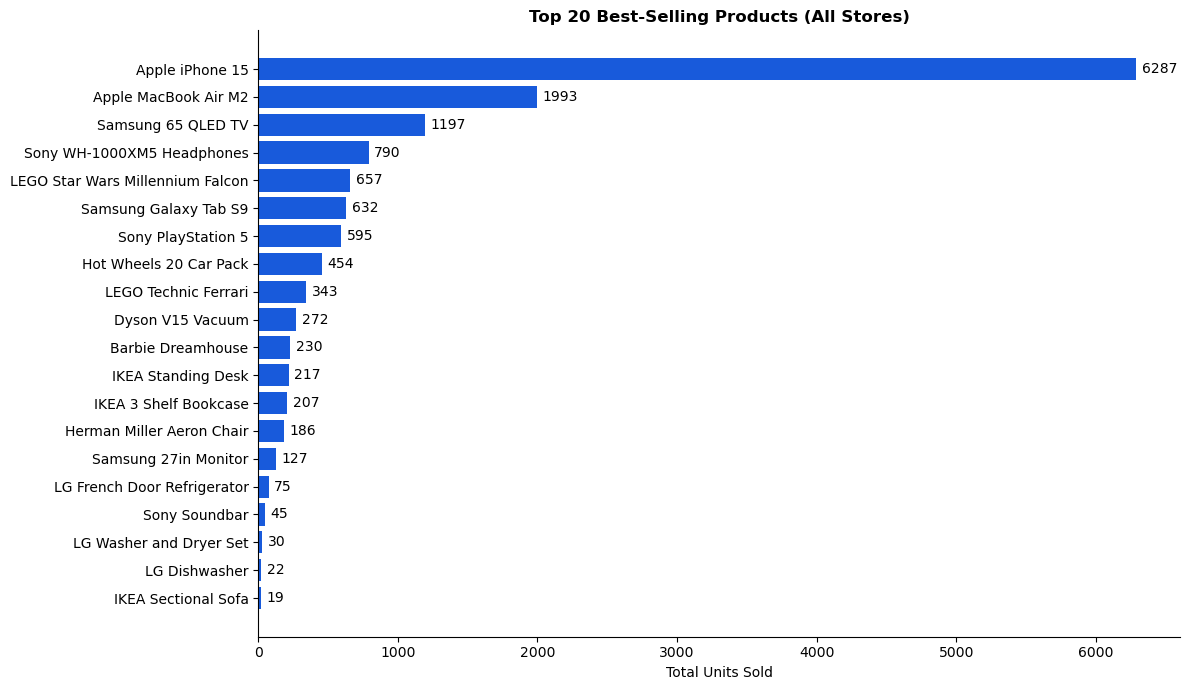

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\4687195.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cnx)


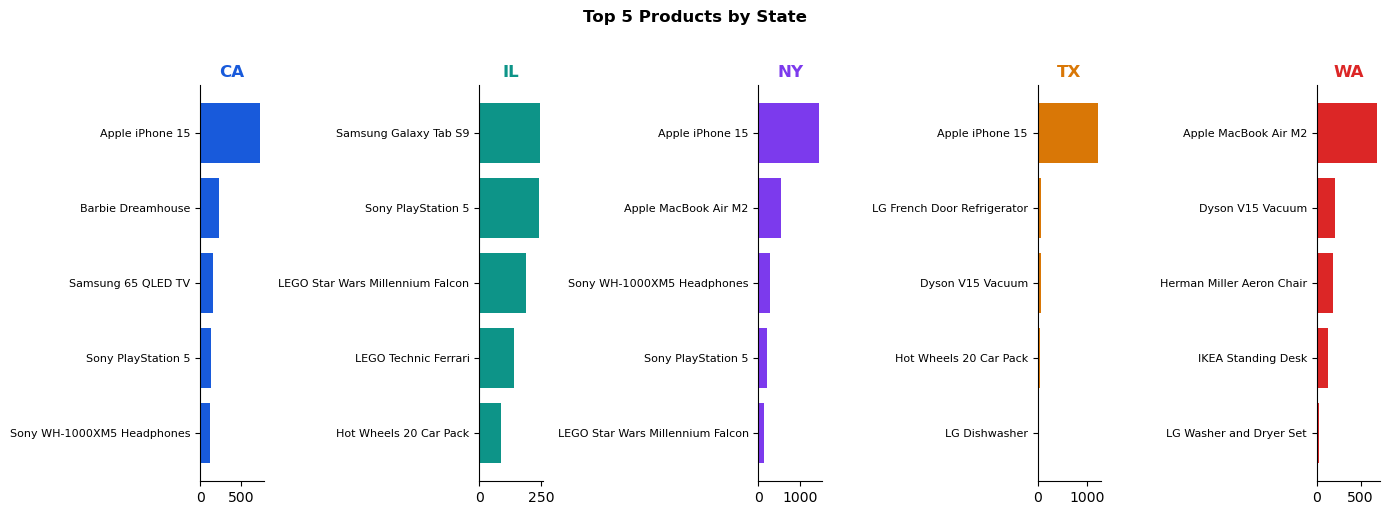

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\4687195.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cnx)


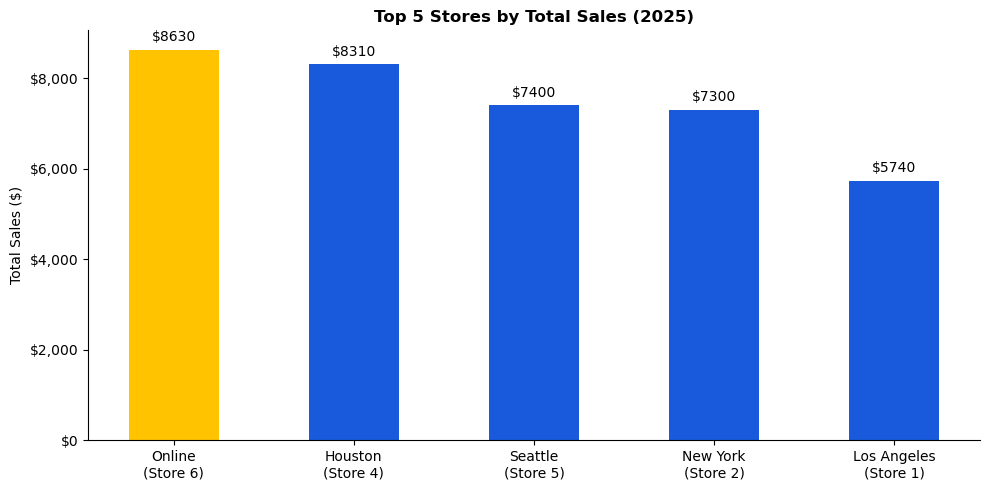

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\4687195.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cnx)


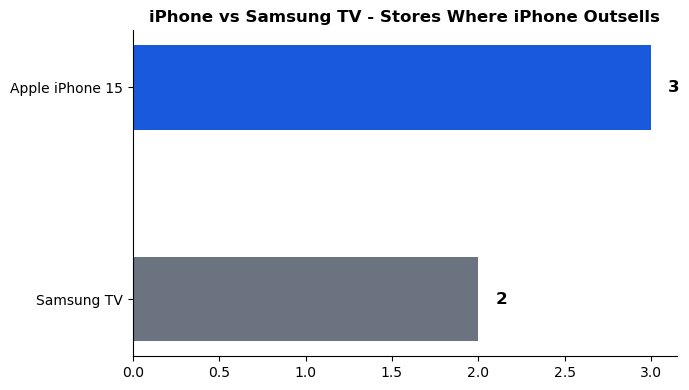

C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\4687195.py:103: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(q, cnx)


iPhone outsells Samsung TV in 3 out of 5 stores


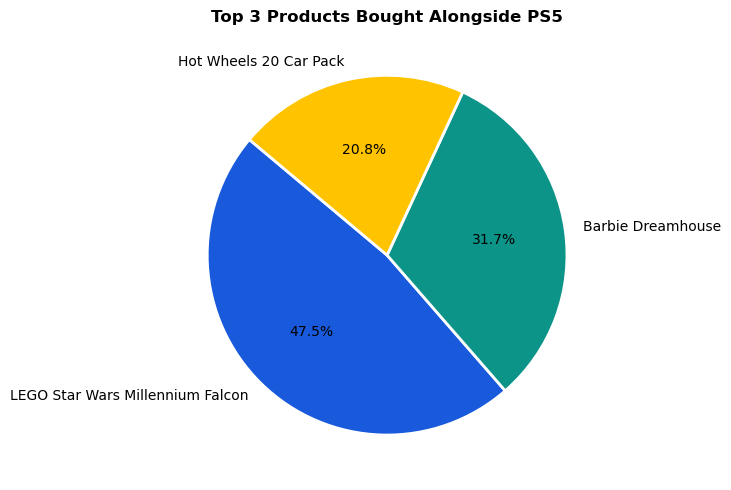


       BESTBUY DATABASE SYSTEM
  1. Place an Order
  2. Run Analytics Queries
  3. View Inventory at a Store
  4. Add Inventory to a Store
  5. Look Up a Customer
  6. View Order History
  7. Exit



Select an option (1-7):  3


C:\Users\Oybek Sobirov\AppData\Local\Temp\ipykernel_20864\92160430.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)



=== Available Stores ===
  1. Los Angeles, CA
  2. New York, NY
  3. Chicago, IL
  4. Houston, TX
  5. Seattle, WA
  6. Online (bestbuy.com)


Select store (1-6):  5


...


=== Add Inventory ===

Available Products:
  1. Samsung 65 QLED TV
  2. Sony WH-1000XM5 Headphones
  3. Apple MacBook Air M2
  4. Samsung Galaxy Tab S9
  5. Sony PlayStation 5
  6. Apple iPhone 15
  7. Samsung 27in Monitor
  8. Sony Soundbar
  9. LG French Door Refrigerator
  10. LG Washer and Dryer Set
  11. Dyson V15 Vacuum
  12. LG Dishwasher
  13. LEGO Star Wars Millennium Falcon
  14. Barbie Dreamhouse
  15. Hot Wheels 20 Car Pack
  16. LEGO Technic Ferrari
  17. Herman Miller Aeron Chair
  18. IKEA Standing Desk
  19. IKEA 3 Shelf Bookcase
  20. IKEA Sectional Sofa

=== Available Stores ===
  1. Los Angeles, CA
  2. New York, NY
  3. Chicago, IL
  4. Houston, TX
  5. Seattle, WA
  6. Online (bestbuy.com)



Store ID (1-6):  5
Product ID:  2


Added 'Sony WH-1000XM5 Headphones' to Store 5

       BESTBUY DATABASE SYSTEM
  1. Place an Order
  2. Run Analytics Queries
  3. View Inventory at a Store
  4. Add Inventory to a Store
  5. Look Up a Customer
  6. View Order History
  7. Exit



Select an option (1-7):  7


Goodbye!


In [10]:
def main_menu():
    while True:
        print("\n" + "=" * 50)
        print("       BESTBUY DATABASE SYSTEM")
        print("=" * 50)
        print("  1. Place an Order")
        print("  2. Run Analytics Queries")
        print("  3. View Inventory at a Store")
        print("  4. Add Inventory to a Store")
        print("  5. Look Up a Customer")
        print("  6. View Order History")
        print("  7. Exit")
        
        choice = input("\nSelect an option (1-7): ")
        
        if choice == '1':
            place_order()
        elif choice == '2':
            run_queries()
        elif choice == '3':
            show_stores()
            sid = int(input("Select store (1-6): "))
            show_inventory(sid)
        elif choice == '4':
            add_inventory()
        elif choice == '5':
            lookup_customer()
        elif choice == '6':
            view_order_history()
        elif choice == '7':
            print("Goodbye!")
            break
        else:
            print("Invalid option. Try again.")

main_menu()